> #### Environment Setup
> Copy the following line to the terminal
> ```cmd
> pip install matplotlib numpy scipy scikit-learn tensorflow yfinance
> ```

# Plan
1. Fetch Data
2. Normality Check — histograms, Q-Q plots, Shapiro-Wilk / D'Agostino / Anderson-Darling
3. Data Preparation — train/test split **before** scaling, RobustScaler (fit on train only), sequence generation per split
4. Build & Train LSTM — two LSTM layers with Dropout, EarlyStopping
5. Predict & Visualize
6. Evaluate — RMSE, MAE, MAPE

---
# 1. Fetching Stock Data

In [1]:
import yfinance as yf

stock_data = yf.download('TSLA', start='2016-01-01', multi_level_index=False)
stock_data

[*********************100%***********************]  1 of 1 completed


,Close,High,Low,Open,Volume
Date,,,,,
2016-01-04,14.894000,15.425333,14.600000,15.381333,102406500
2016-01-05,14.895333,15.126000,14.666667,15.090667,47802000
2016-01-06,14.602667,14.670000,14.398667,14.666667,56686500
2016-01-07,14.376667,14.562667,14.244667,14.279333,53314500
2016-01-08,14.066667,14.696000,14.051333,14.524000,54421500
...,...,...,...,...,...
2026-03-24,383.029999,387.480011,376.309998,376.559998,60004900
2026-03-25,385.950012,396.230011,385.010010,389.989990,55157300
2026-03-26,372.109985,384.440002,371.869995,381.600006,55522900


---
# 2. Normality Check
Run three normality tests per feature and visualise with histograms + Q-Q plots.

C:\Users\hp\AppData\Local\Temp\ipykernel_30044\4180325108.py:34: FutureWarning: As of SciPy 1.17, users must choose a p-value calculation method by providing the `method` parameter. `method='interpolate'` interpolates the p-value from pre-calculated tables; `method` may also be an instance of `MonteCarloMethod` to approximate the p-value via Monte Carlo simulation. When `method` is specified, the result object will include a `pvalue` attribute and not attributes `critical_value`, `significance_level`, or `fit_result`. Beginning in 1.19.0, these other attributes will no longer be available, and a p-value will always be computed according to one of the available `method` options.
  ad = anderson(data, dist='norm')


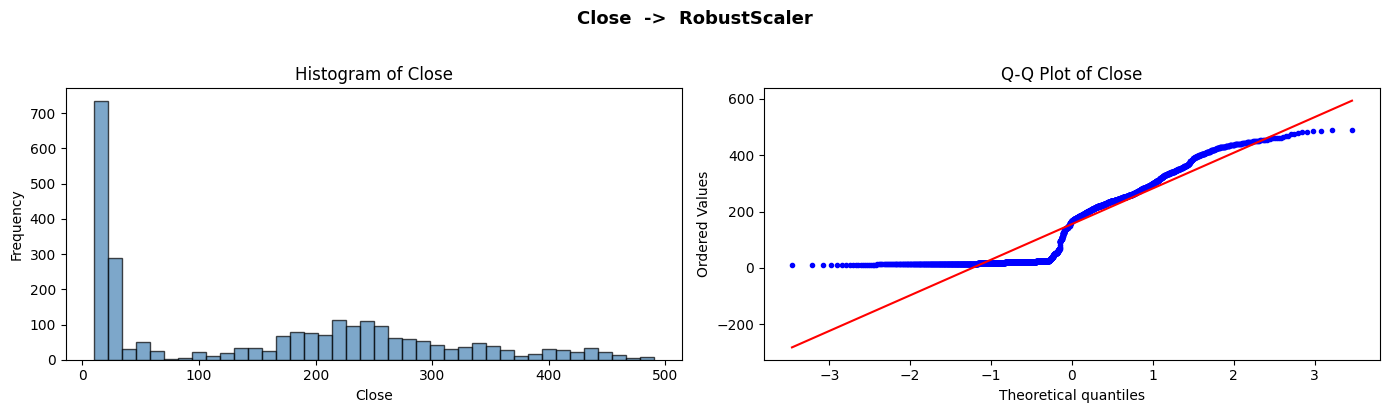

  Shapiro-Wilk     p = 4.8161e-42  NOT normal
  D'Agostino       p = 5.2602e-168  NOT normal
  Anderson-Darling   = 127.6778  (crit 5% = 0.7520)  NOT normal
  -> Recommended scaler: RobustScaler
----------------------------------------------------------------------


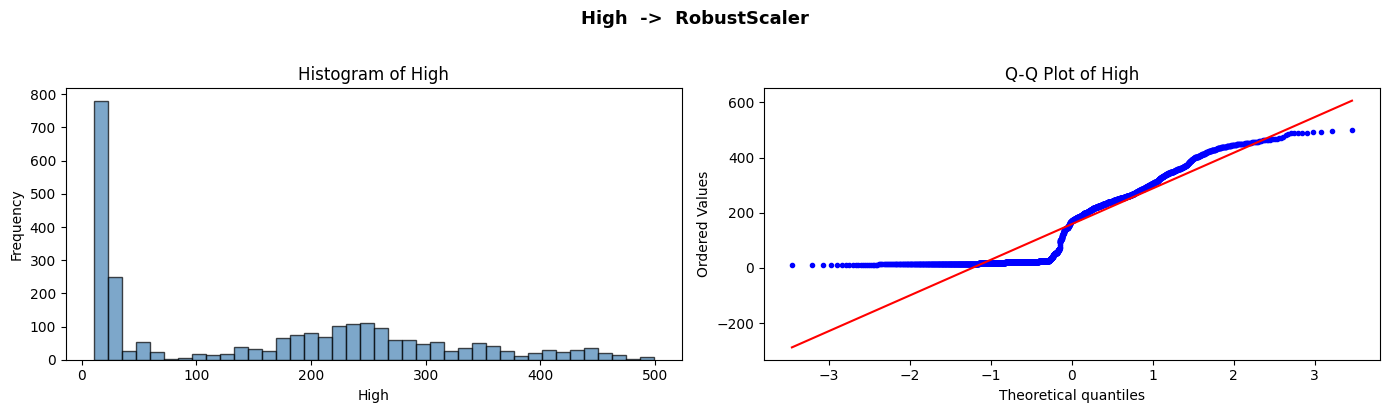

  Shapiro-Wilk     p = 4.7093e-42  NOT normal
  D'Agostino       p = 6.4589e-176  NOT normal
  Anderson-Darling   = 127.6664  (crit 5% = 0.7520)  NOT normal
  -> Recommended scaler: RobustScaler
----------------------------------------------------------------------


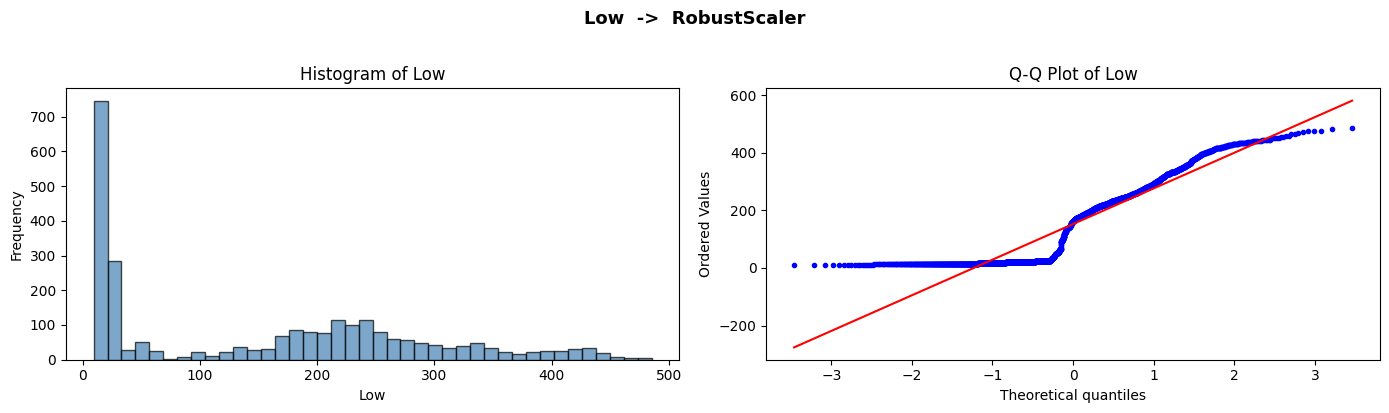

  Shapiro-Wilk     p = 4.8062e-42  NOT normal
  D'Agostino       p = 4.8552e-159  NOT normal
  Anderson-Darling   = 127.6306  (crit 5% = 0.7520)  NOT normal
  -> Recommended scaler: RobustScaler
----------------------------------------------------------------------


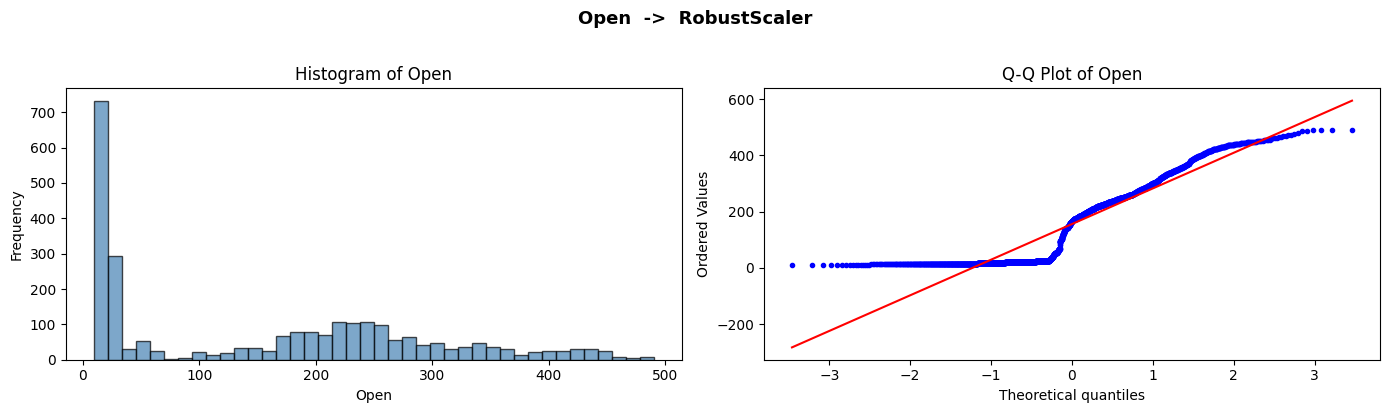

  Shapiro-Wilk     p = 4.8618e-42  NOT normal
  D'Agostino       p = 2.7581e-164  NOT normal
  Anderson-Darling   = 127.5475  (crit 5% = 0.7520)  NOT normal
  -> Recommended scaler: RobustScaler
----------------------------------------------------------------------


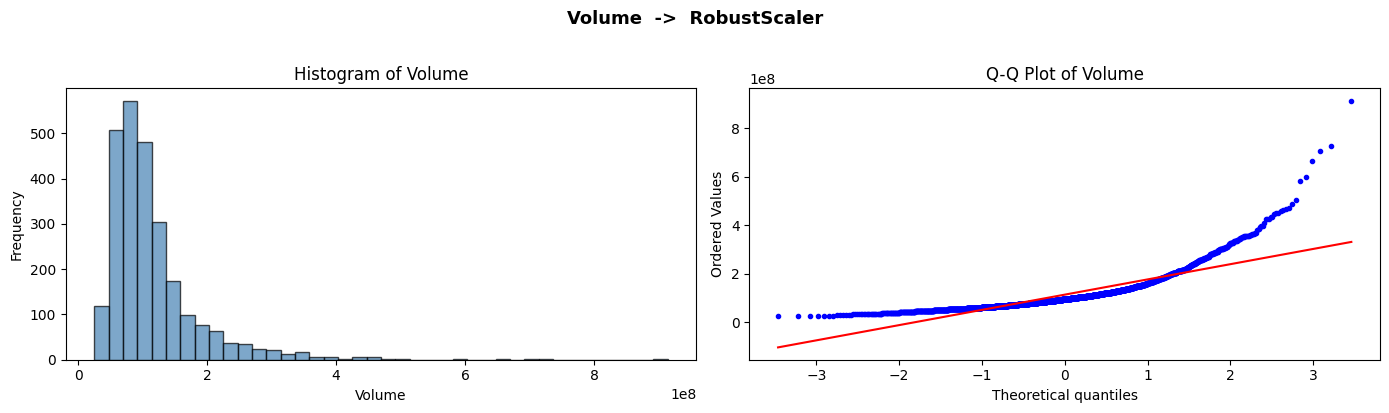

  Shapiro-Wilk     p = 3.8655e-52  NOT normal
  D'Agostino       p = 0.0000e+00  NOT normal
  Anderson-Darling   = 148.6552  (crit 5% = 0.7520)  NOT normal
  -> Recommended scaler: RobustScaler
----------------------------------------------------------------------

SUMMARY
Feature  Shapiro p D'Agostino p Anderson stat AD critical 5%  Recommended
  Close 4.8161e-42  5.2602e-168      127.6778         0.7520 RobustScaler
   High 4.7093e-42  6.4589e-176      127.6664         0.7520 RobustScaler
    Low 4.8062e-42  4.8552e-159      127.6306         0.7520 RobustScaler
   Open 4.8618e-42  2.7581e-164      127.5475         0.7520 RobustScaler
 Volume 3.8655e-52   0.0000e+00      148.6552         0.7520 RobustScaler


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import shapiro, normaltest, anderson
from scipy import stats

SIGNIFICANCE = 0.05
SHAPIRO_MAX = 5000


def recommend_scaler(shapiro_p, dagostino_p, ad_normal):
    normal_votes = sum([shapiro_p > SIGNIFICANCE,
                        dagostino_p > SIGNIFICANCE,
                        ad_normal])
    if normal_votes >= 2:
        return "StandardScaler"
    return "RobustScaler"


summary_rows = []

for col in stock_data.columns:
    data = stock_data[col].values.astype(float)

    # Shapiro-Wilk (cap sample)
    shapiro_sample = (np.random.choice(data, SHAPIRO_MAX, replace=False)
                      if len(data) > SHAPIRO_MAX else data)
    _, shapiro_p = shapiro(shapiro_sample)

    # D'Agostino-Pearson
    _, dagostino_p = normaltest(data)

    # Anderson-Darling
    ad = anderson(data, dist='norm')
    ad_normal = ad.statistic < ad.critical_values[2]  # 5 % level

    scaler = recommend_scaler(shapiro_p, dagostino_p, ad_normal)
    summary_rows.append({'Feature': col,
                         'Shapiro p': f'{shapiro_p:.4e}',
                         "D'Agostino p": f'{dagostino_p:.4e}',
                         'Anderson stat': f'{ad.statistic:.4f}',
                         'AD critical 5%': f'{ad.critical_values[2]:.4f}',
                         'Recommended': scaler})

    # Plot
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    axes[0].hist(data, bins=40, edgecolor='black', alpha=0.7, color='steelblue')
    axes[0].set_title(f'Histogram of {col}')
    axes[0].set_xlabel(col)
    axes[0].set_ylabel('Frequency')

    stats.probplot(data, dist='norm', plot=axes[1])
    axes[1].set_title(f'Q-Q Plot of {col}')
    axes[1].get_lines()[0].set_markersize(3.0)

    plt.suptitle(f'{col}  ->  {scaler}', fontsize=13, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

    print(f'  Shapiro-Wilk     p = {shapiro_p:.4e}  {"normal" if shapiro_p > SIGNIFICANCE else "NOT normal"}')
    print(f"  D'Agostino       p = {dagostino_p:.4e}  {'normal' if dagostino_p > SIGNIFICANCE else 'NOT normal'}")
    print(f'  Anderson-Darling   = {ad.statistic:.4f}  (crit 5% = {ad.critical_values[2]:.4f})  {"normal" if ad_normal else "NOT normal"}')
    print(f'  -> Recommended scaler: {scaler}')
    print('-' * 70)

summary_df = pd.DataFrame(summary_rows)
print('\n' + '=' * 80)
print('SUMMARY')
print('=' * 80)
print(summary_df.to_string(index=False))

---
# 3. Data Preparation
Split **before** scaling to prevent data leakage. Use separate scalers for input features and the target column.

## 3.1 Imports & Configuration

In [3]:
import numpy as np
from sklearn.preprocessing import RobustScaler

LOOKBACK = 60
TRAIN_RATIO = 0.8

stock_data['Close_nxt'] = stock_data['Close'].shift(-1)
stock_data = stock_data.dropna(subset=['Close_nxt'])

feature_cols = ['Open', 'High', 'Low', 'Volume']
target_col = ['Close_nxt']

## 3.2 Train / Test Split (time-based, before scaling)

In [4]:
split_idx = int(len(stock_data) * TRAIN_RATIO)

train_features_raw = stock_data[feature_cols].values[:split_idx]
test_features_raw  = stock_data[feature_cols].values[split_idx:]

train_target_raw = stock_data[target_col].values[:split_idx]
test_target_raw  = stock_data[target_col].values[split_idx:]

print(f'Train samples : {len(train_features_raw)}')
print(f'Test  samples : {len(test_features_raw)}')

Train samples : 2058
Test  samples : 515


## 3.3 Feature Scaling — fit on train only

In [5]:
# Separate scalers so inverse_transform on the target works on 1 column
feature_scaler = RobustScaler()
target_scaler = RobustScaler()

train_features = feature_scaler.fit_transform(train_features_raw)
test_features  = feature_scaler.transform(test_features_raw)

train_target = target_scaler.fit_transform(train_target_raw)
test_target  = target_scaler.transform(test_target_raw)

print(f'Train features shape: {train_features.shape}')
print(f'Train target shape  : {train_target.shape}')

Train features shape: (2058, 4)
Train target shape  : (2058, 1)


## 3.4 Sequence Generation
Pad the test input with the last `LOOKBACK` rows from training so the first test sequence uses only train-era data.

In [6]:
def create_sequences(features, target, lookback):
    X, y = [], []
    for i in range(lookback, len(features)):
        X.append(features[i - lookback:i])
        y.append(target[i, 0])
    return np.array(X), np.array(y)


# Training sequences
X_train, y_train = create_sequences(train_features, train_target, LOOKBACK)

# Test sequences — prepend last LOOKBACK rows from train to avoid boundary leakage
test_features_padded = np.concatenate([train_features[-LOOKBACK:], test_features])
test_target_padded = np.concatenate([train_target[-LOOKBACK:], test_target])
X_test, y_test = create_sequences(test_features_padded, test_target_padded, LOOKBACK)

print(f'X_train: {X_train.shape}  y_train: {y_train.shape}')
print(f'X_test : {X_test.shape}  y_test : {y_test.shape}')

X_train: (1998, 60, 4)  y_train: (1998,)
X_test : (515, 60, 4)  y_test : (515,)


---
# 4. Building and Training LSTM

In [7]:
from keras.models import Sequential
from keras.layers import LSTM, Dense, Dropout, Input
from keras.callbacks import EarlyStopping

model = Sequential([
    Input(shape=(LOOKBACK, X_train.shape[2])),
    LSTM(100, return_sequences=True),
    Dropout(0.2),
    LSTM(100, return_sequences=False),
    Dropout(0.2),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse', metrics=['mae'])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 100)        │        42,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 100)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 100)            │        80,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 122,501 (478.52 KB)

 Trainable params: 122,501 (478.52 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    validation_split=0.1,
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 32s 229ms/step - loss: 0.0284 - mae: 0.0912 - val_loss: 0.0076 - val_mae: 0.0708
Epoch 2/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 9s 164ms/step - loss: 0.0072 - mae: 0.0503 - val_loss: 0.0136 - val_mae: 0.0950
Epoch 3/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 15s 258ms/step - loss: 0.0078 - mae: 0.0513 - val_loss: 0.0109 - val_mae: 0.0868
Epoch 4/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 9s 155ms/step - loss: 0.0060 - mae: 0.0450 - val_loss: 0.0093 - val_mae: 0.0763
Epoch 5/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 14s 221ms/step - loss: 0.0082 - mae: 0.0538 - val_loss: 0.0062 - val_mae: 0.0648
Epoch 6/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 18s 171ms/step - loss: 0.0062 - mae: 0.0465 - val_loss: 0.0051 - val_mae: 0.0584
Epoch 7/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 13s 207ms/step - loss: 0.0063 - mae: 0.0468 - val_loss: 0.0046 - val_mae: 0.0542
Epoch 8/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 20s 190ms/step - loss: 0.0063 - mae: 0.0476 - val_loss: 0.0056 - val_mae: 0.0614
Epoch 9/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 19s

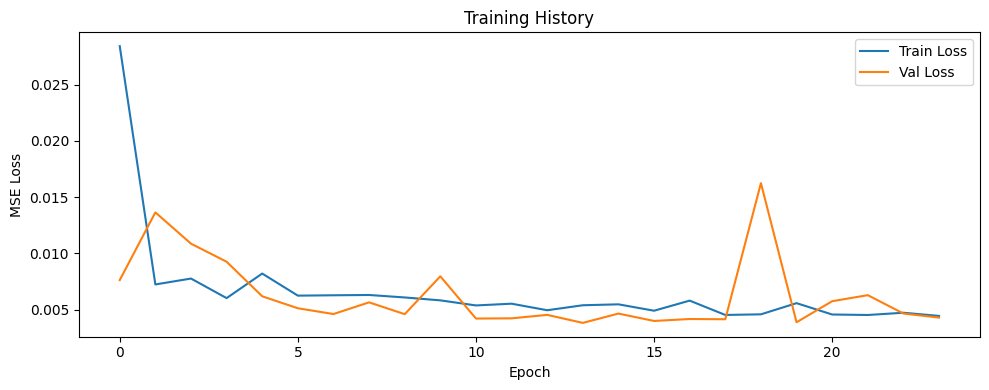

In [9]:
plt.figure(figsize=(10, 4))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Training History')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.tight_layout()
plt.show()

---
# 5. Making Predictions

In [10]:
pred_scaled = model.predict(X_test)

# Inverse-transform using the target scaler (fit on 1 column)
prediction = target_scaler.inverse_transform(pred_scaled)
y_test_actual = target_scaler.inverse_transform(y_test.reshape(-1, 1))

print(f'Predictions shape: {prediction.shape}')
print(f'Actuals shape     : {y_test_actual.shape}')

17/17 ━━━━━━━━━━━━━━━━━━━━ 14s 409ms/step
Predictions shape: (515, 1)
Actuals shape     : (515, 1)


---
# 6. Visualisation

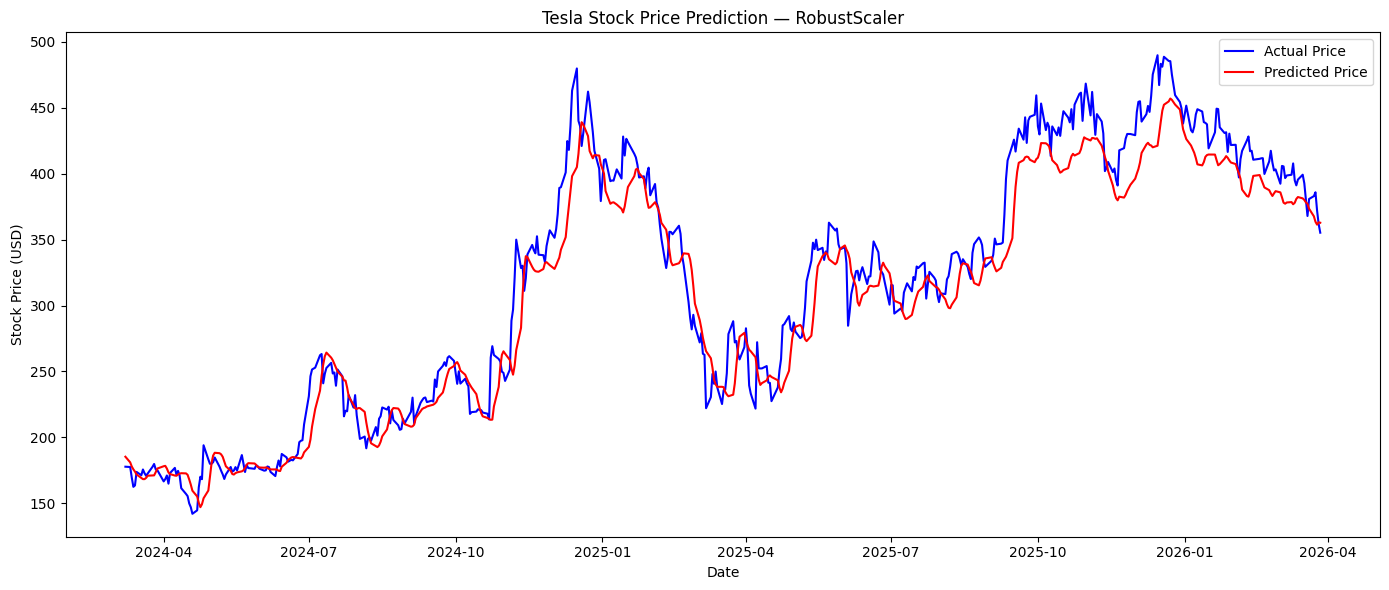

In [11]:
test_dates = stock_data.index[split_idx:]

plt.figure(figsize=(14, 6))
plt.plot(test_dates, y_test_actual.flatten(), label='Actual Price', color='blue')
plt.plot(test_dates, prediction.flatten(), label='Predicted Price', color='red')
plt.title('Tesla Stock Price Prediction — RobustScaler')
plt.xlabel('Date')
plt.ylabel('Stock Price (USD)')
plt.legend()
plt.tight_layout()
plt.show()

---
# 7. Model Evaluation

In [12]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

mse  = mean_squared_error(y_test_actual, prediction)
rmse = np.sqrt(mse)
mae  = mean_absolute_error(y_test_actual, prediction)
mape = np.mean(np.abs((y_test_actual - prediction) / y_test_actual)) * 100

print('=' * 45)
print('LSTM with RobustScaler — Test Metrics')
print('=' * 45)
print(f'  MSE  : {mse:.4f}')
print(f'  RMSE : {rmse:.4f}')
print(f'  MAE  : {mae:.4f}')
print(f'  MAPE : {mape:.2f}%')
print('=' * 45)

LSTM with RobustScaler — Test Metrics
  MSE  : 562.6013
  RMSE : 23.7192
  MAE  : 18.1744
  MAPE : 5.61%


17/17 ━━━━━━━━━━━━━━━━━━━━ 3s 134ms/step


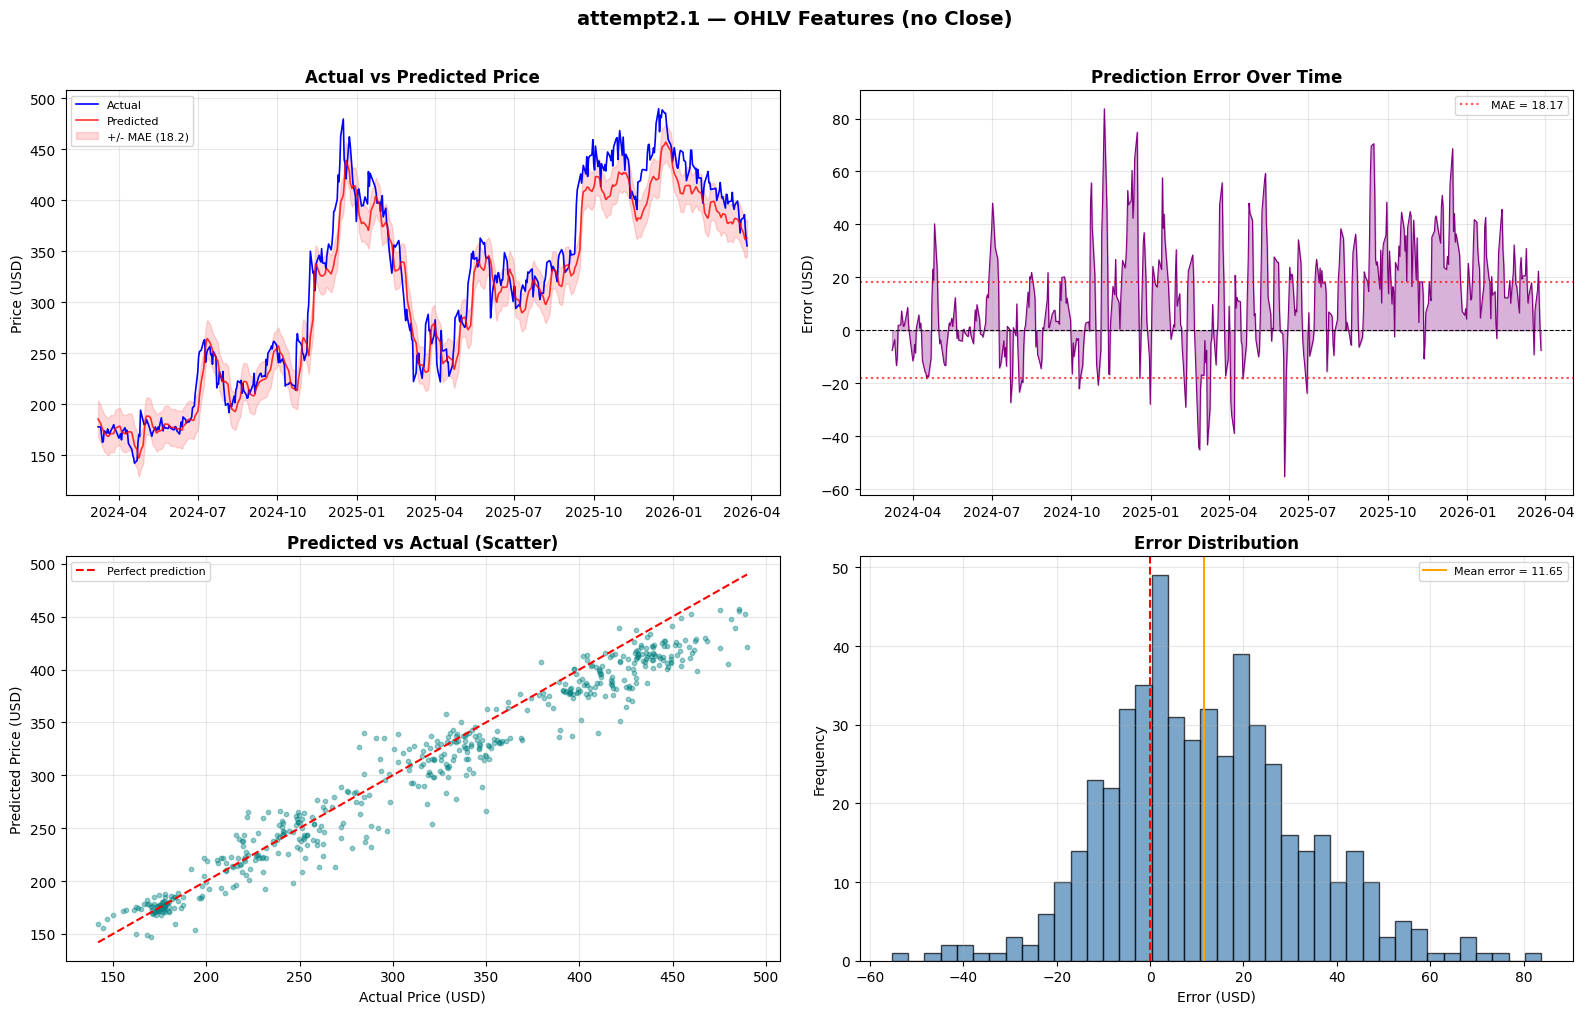

Mean Error: 11.6470  |  Std Error: 20.6627
Max Over-prediction: 83.7013  |  Max Under-prediction: -55.2377
Mean Abs % Error: 5.61%


In [13]:
# Detailed Prediction Visualization
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Re-compute predictions and metrics so this cell works standalone
pred_scaled = model.predict(X_test)
prediction = target_scaler.inverse_transform(pred_scaled)
y_test_actual = target_scaler.inverse_transform(y_test.reshape(-1, 1))
test_dates = stock_data.index[split_idx:]

mse  = mean_squared_error(y_test_actual, prediction)
rmse = np.sqrt(mse)
mae  = mean_absolute_error(y_test_actual, prediction)
mape = np.mean(np.abs((y_test_actual - prediction) / y_test_actual)) * 100

errors = y_test_actual.flatten() - prediction.flatten()
pct_errors = (errors / y_test_actual.flatten()) * 100

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. Actual vs Predicted
ax = axes[0, 0]
ax.plot(test_dates, y_test_actual.flatten(), label='Actual', color='blue', linewidth=1.2)
ax.plot(test_dates, prediction.flatten(), label='Predicted', color='red', linewidth=1.2, alpha=0.8)
ax.fill_between(test_dates, prediction.flatten() - mae, prediction.flatten() + mae,
                alpha=0.15, color='red', label=f'+/- MAE ({mae:.1f})')
ax.set_title('Actual vs Predicted Price', fontweight='bold')
ax.set_ylabel('Price (USD)')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

# 2. Prediction Error Over Time
ax = axes[0, 1]
ax.plot(test_dates, errors, color='purple', linewidth=0.8)
ax.axhline(y=0, color='black', linestyle='--', linewidth=0.8)
ax.axhline(y=mae, color='red', linestyle=':', alpha=0.7, label=f'MAE = {mae:.2f}')
ax.axhline(y=-mae, color='red', linestyle=':', alpha=0.7)
ax.fill_between(test_dates, errors, 0, alpha=0.3, color='purple')
ax.set_title('Prediction Error Over Time', fontweight='bold')
ax.set_ylabel('Error (USD)')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

# 3. Scatter: Predicted vs Actual
ax = axes[1, 0]
ax.scatter(y_test_actual.flatten(), prediction.flatten(), alpha=0.4, s=10, color='teal')
min_val = min(y_test_actual.min(), prediction.min())
max_val = max(y_test_actual.max(), prediction.max())
ax.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=1.5, label='Perfect prediction')
ax.set_xlabel('Actual Price (USD)')
ax.set_ylabel('Predicted Price (USD)')
ax.set_title('Predicted vs Actual (Scatter)', fontweight='bold')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

# 4. Error Distribution
ax = axes[1, 1]
ax.hist(errors, bins=40, edgecolor='black', alpha=0.7, color='steelblue')
ax.axvline(x=0, color='red', linestyle='--', linewidth=1.5)
ax.axvline(x=errors.mean(), color='orange', linestyle='-', linewidth=1.5,
           label=f'Mean error = {errors.mean():.2f}')
ax.set_xlabel('Error (USD)')
ax.set_ylabel('Frequency')
ax.set_title('Error Distribution', fontweight='bold')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

plt.suptitle('attempt2.1 — OHLV Features (no Close)', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# Summary stats
print(f'Mean Error: {errors.mean():.4f}  |  Std Error: {errors.std():.4f}')
print(f'Max Over-prediction: {errors.max():.4f}  |  Max Under-prediction: {errors.min():.4f}')
print(f'Mean Abs % Error: {np.abs(pct_errors).mean():.2f}%')